---
title: "Chapter 5: Unsupervised Learning. Part 1"
subtitle: "Machine Learning"
date: "April 2026"
date-format: "MMMM YYYY"
author: 
  - F.San Segundo & N.Rodríguez
execute:
  echo: true
code-overflow: wrap
format: 
  beamer:
    linkcolor: orange
    theme: Madrid
    keep-tex: true
    pdf-engine: lualatex
    fig-align: center
    fontsize: 8pt
    include-in-header:
        - file: "../beamer-header-simple.txt"
  pdf:
    toc: true
    linkcolor: orange
    fig-align: center
    fontsize: 10pt
  html: 
    toc: true
    code-tools: true
    embed-resources: true
---


In [ ]:
%cd 5_2_Unsupervised_Clustering

/wd/5_2_Unsupervised_Clustering



## 5.2 Clustering Methods

Clustering is a very common form of unsupervised learning. It aims to find a natural grouping in data so that the items in the same cluster are more similar to each other than to those from different clusters. 

There are two main categories of clustering:
* **Prototype-based** clustering: Each cluster is represented by a prototype. Usually, this prototype is:
    - The centroid (average) of similar points with continuous features
    - The medoid (the point that minimises the distance to the other points in a cluster)

* **Hierarchical**: This technique allows us to plot **dendrograms**. There are two main approaches: 
    - Divisive: We start with one cluster (all the dataset) and we iteratively split this cluster until each cluster only contains one example. 
    - Agglomerative: The opposite to divisive. We start with clusters of just one example each, and we iteratively merge these clusters until only one cluster remains. 



---

## 5.2.1 K Means Clustering



We assume there are $K$ cluster centers $μ_{k} \in \mathbb{R}^{D}$, so we can cluster the data by assigning each data point $x_{n} \in \mathbb{R}^{D}$ to it closest center:

$$ z_{n}^{*} = \text{argmin}_{k} || \vec{x}_{n} - \vec{\mu}_{k} ||^{2}$$

Of course, we don’t know the cluster centers, but we can estimate them by computing the average value of all points assigned to them:

$$ \vec{\mu}_{k} = \frac{1}{N_{k}} \sum_{n:z_{n} = k} \vec{x}_{n}$$

We can then iterate these steps to convergence. 

More formally, we can view this as finding a local minimum of the following cost function, known as the **distortion**: 

$$ J(\mathbf{M}, \mathbf{Z}) = \sum_{n=1}^{N} || \vec{x}_{n} - \vec{\mu}_{z_{n}} ||^{2} = || \mathbf{X} - \mathbf{Z}\mathbf{M}^{T} || ^{2} $$

where $\mathbf{X} \in \mathbb{R}^{N \times D}$, $\mathbf{Z} \in [0, 1]^{N \times K}$, and $\mathbf{M} \in \mathbb{R}^{D\times K}$ containes the clusters centers $\vec{\mu}_{k}$ in its columns. 

K-Means optimises this using alternating minimisation. From a theoretical perspective, finding the optimal solution for a clustering problem is particularly difficult (NP-hard). 

Thus, all algorithms are only approximations of the optimal solution. The k-means algorithm, is an iterative process that refines the solution until it converges to a local optimum.

**Some properties of K-means:**
* Clusters do not overlap
* Clusters are not hierarchical
* It is assumed that there is at least one item in each cluster

---

**Four steps:**

1. Specify the number $k$ of clusters to assign. 
2. Randomly initialise $k$ centroids.
3. **repeat**
   1. **expectation**: Assign each point to its closest centroid. 
   2. **maximisation**: Compute the new centroid (mean) of each cluster.
4. **until** The centroid positions do not change or a user-defined tolerance or maximum number of iterations is reached.

---

### 5.2.1.1 Example

#### Handmade implementation

We are goint to apply these steps through an example. The following code just creates a dataset to work with. 

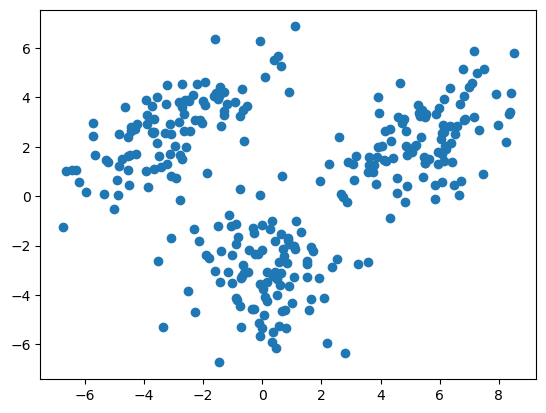

In [2]:
%run -i "example_kmeans.py"

- **Initialization**: Often, there is no good prior knowledge about the location of the centroids. An effortless way to start is to define the centroids by randomly selecting  data points from the dataset (Forgy method).

In [3]:
def pick_centroids(data, k):
    indexes = np.random.choice(len(data), size=k, replace=False)
    centroids = data[indexes]
    return centroids


::: {.callout-tip  icon=false}

#### Think about it

What do you think about randomly selecting data points as the initial centroids? Is there a better approach?

:::

- **Assignment**: For each data point, the distance to all centroids is computed. The data points belong to the cluster represented by the closest centroid. This is called a **hard** assignment because the data point belongs to one and only one cluster.

In [4]:
def assign_cluster(data, centroids):
    # Pairwise squared L2 distances. Shape [n, k]
    distances = ((data[:, np.newaxis] - centroids)**2).sum(axis=2)
    # find closest centroid index. Shape [n]
    clusters = np.argmin(distances, axis=1)
    return clusters


::: {.callout-tip  icon=false}

#### Question

If there is a hard assignment, intuition tells us that there must be something called "soft assignment"...What's the difference?

:::

- **Update**: Given all the points assigned to a cluster, the mean position is computed and defines the new location of the centroid. All centroids are updated simultaneously. 


In [5]:
def update_centroids(data, clusters, k):
    # Mean positions of data within clusters
    centroids = [np.mean(data[clusters == i], axis=0) for i in range(k)]
    return np.array(centroids)

Using the two functions defined above, we can create an object `KMEANS` with methods `fit` and `predict`

In [6]:
class KMEANS:
    def __init__(self, k):
        self.k = k
        
    def fit(self, data, steps=20):
        self.centroids = pick_centroids(data, self.k)
        for step in range(steps):
            clusters = assign_cluster(data, self.centroids)
            self.centroids = update_centroids(data, clusters, self.k)
            
    def predict(self, data):
        return assign_cluster(data, self.centroids)
    

Similarly to what we do with scikit-learn...

In [7]:
kmeans = KMEANS(k=3)
kmeans.fit(data)
clusters = kmeans.predict(data)

We can plot the results of K-Means applied to the data: 

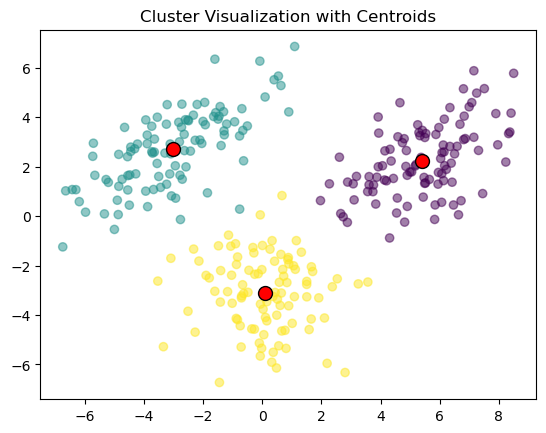

In [8]:
import matplotlib.pyplot as plt
plt.scatter(data[:, 0], data[:, 1], c=clusters, cmap='viridis', alpha=0.5) 
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c="red", s=100, edgecolor='black', label='Centroids')
plt.title('Cluster Visualization with Centroids')  
plt.grid(False)
plt.show()

It is possible to visualize the decision boundaries of K-Means. For this, we can use a **Voronoi diagram**

::: {.callout-note icon=false}

#### Voronoi diagram

A Voronoi diagram is a way of dividing space into regions based on the distances to a specified set of points, often referred to as sites or seeds. In the case of K-Means, the seeds are the centroids of the clusters. 

::: 

In [9]:
def plot_decision_boundaries(clusterer, X, resolution=1000):
    plt.figure()
    mins = X.min(axis=0) - 0.2
    maxs = X.max(axis=0) + 0.2
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution), np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.title('Cluster Visualization with Voronoi cells') 
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), linewidths=1, colors="k")
    plt.scatter(data[:, 0], data[:, 1], c=clusters, cmap='viridis', alpha=0.5) 
    plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c="red", s=100, edgecolor='black', label='Centroids')
    plt.show()
    

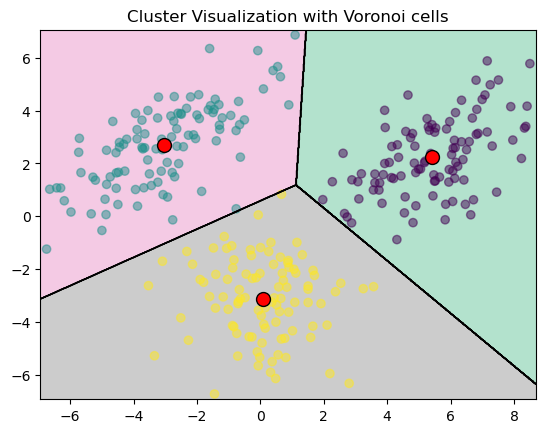

In [10]:
plot_decision_boundaries(kmeans, data)

#### Sklearn Implementation

In [11]:
from sklearn.cluster import KMeans
import numpy as np

kmeans_sklearn = KMeans(n_clusters=2, init='random', n_init=10, random_state=29).fit(data)
kmeans_sklearn.predict(data)
kmeans_sklearn.cluster_centers_

array([[-1.59817374, -0.31619435],
       [ 5.12675506,  2.38537409]])

::: {.callout-tip  icon=false}

#### Question

Inspect the code above. What does the `init` parameter do? And `n_init`? 
(Tip: go to the description of `KMeans` in Scikit-Learn documentation)

:::

::: {.callout-note icon=false}

#### K-Means++

Here we have seen the classic K-means algorithm. However, the default algorithm used by Sklearn when calling KMeans is K-Means++. 

In an nutshell, K-Means++ places the initial centroids far away from each other, leading to better and more consistent results than the classic algorithm.

Interesting link: [What is kmeans++](https://www.youtube.com/watch?v=4qJWhvFQb9g&t=0s)

::: 

### 5.2.1.2 Selecting a good number of clusters

In this section, we discuss how to choose the number of clusters K in the K-means algorithm and other related methods. We will see two main methods:
* The elbow method
* Silhouette plot method

#### The elbow method

This method should already be familiar to you. We can compare the performance of different k-means clustering (different number of clusters) by using the within-cluster Squared Standard Error (SSE), also called **distortion**. 


Since we are using Sklearn, the distortion is already accessible via the `inertia_` attribute of the Kmeans model. Therefore, we can plot this distortion for different values of *k*

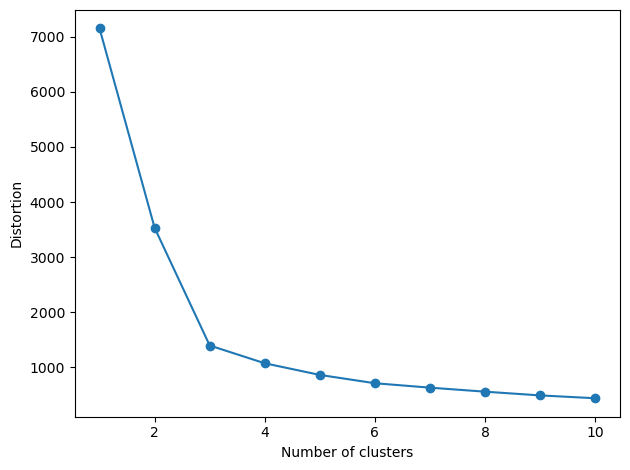

In [12]:
distortions = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, init="k-means++", n_init=10, max_iter=300, random_state=0)
    km.fit(data)
    distortions.append(km.inertia_)

plt.plot(range(1,11), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.tight_layout()
plt.show()

We can see that the elbow is located at $k=3$, so it would be a good choice for this dataset

#### The Silhouette plot method

The Silhouette method can be used to plot a measure of how tightly grouped the examples in the clusters are. It is designed to work for spherical (not elongated) clusters. 


To do this, we have to define the **Silhouette coefficient** as:

$$sc(i) = \frac{b_{i} - a_{i}}{\text{max}(a_{i}, b_{i})}$$

where $a_{i}$ is the mean distance to the other instances in the same cluster, thus it is a measure of **compactness** of the $i$'s cluster, and $b_{i}$ is a **measure of distance** between the clusters (average distance between the example and all the instances in the nearest cluster). 

The silhouette coefficient varies from $-1$ to $+1$ where: 
- $1$ means instance is close to all the members of its cluster and far from other clusters. 
- $0$ means it is close to a cluster boundary. 
- $-1$ means it may be in the wrong cluster. 


Let's see this through an example. The code in the next cell creates a dataset whith some elongated clusters for demonstration purposes:

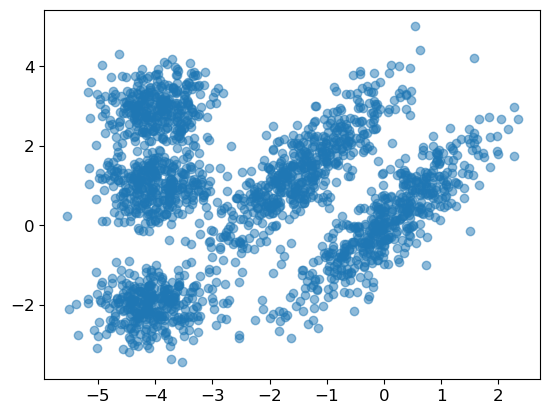

In [13]:
%run -i "example_silhouette.py"

Before plotting the silhouette plots, let's see first the number of clusters given by the **elbow method**

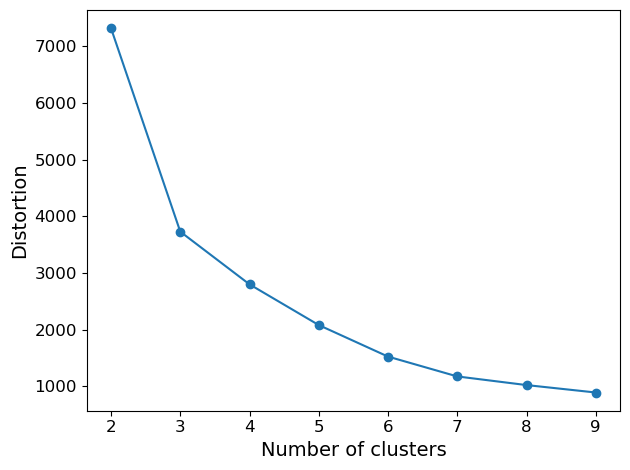

In [14]:
distortions = []
for i in range(2, 10):
    km = KMeans(n_clusters=i, n_init=10, random_state=42)
    km.fit(X)
    distortions.append(km.inertia_)

plt.plot(range(2,10), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.tight_layout()
plt.show()

Let's now plot the silhouette coefficients for each number of clusters $k$

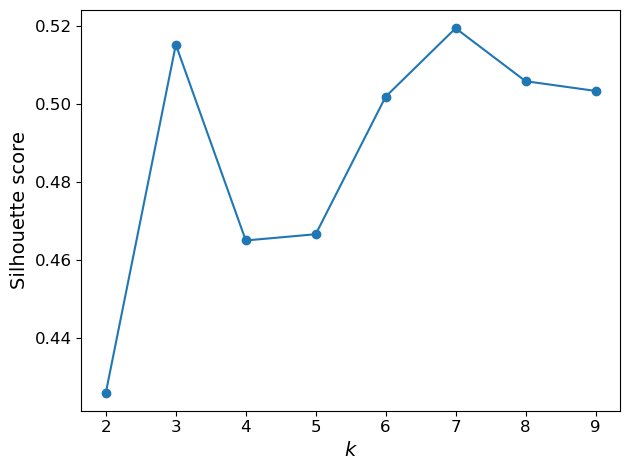

In [15]:
from sklearn.metrics import silhouette_score

Ks = range(2, 10)
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in Ks]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k]

plt.figure()
plt.plot(Ks, silhouette_scores, marker='o')
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.tight_layout()
plt.show()

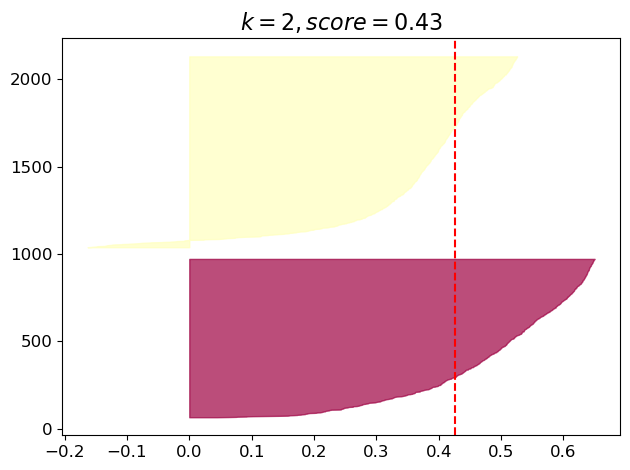

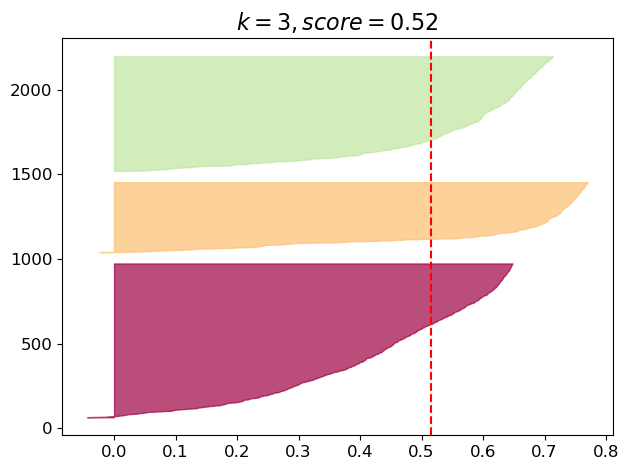

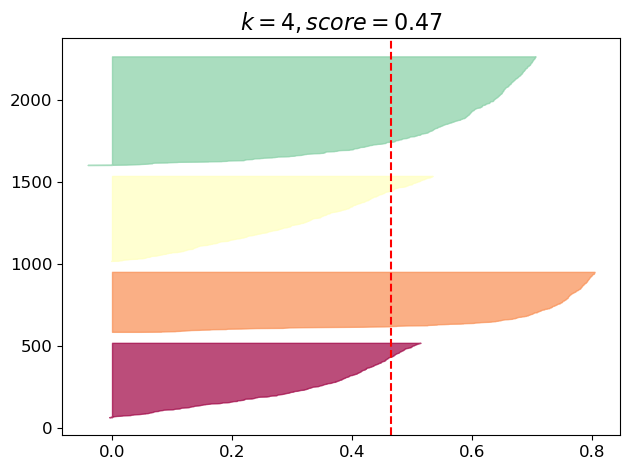

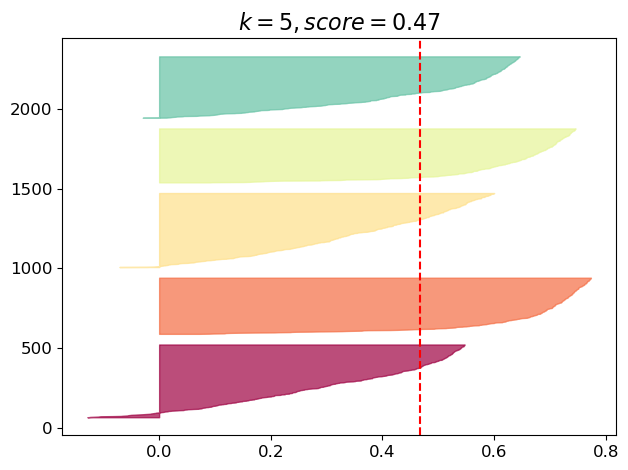

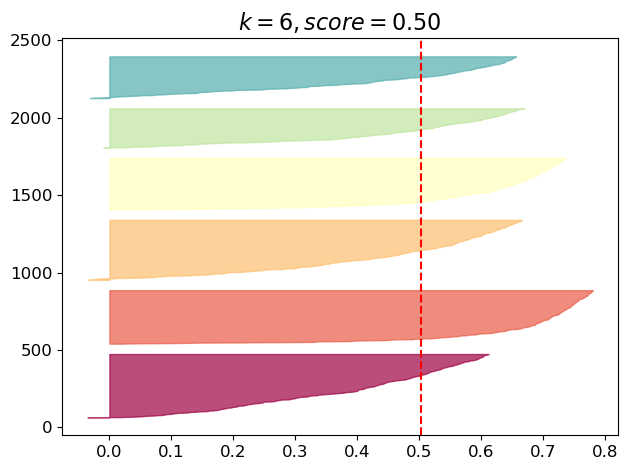

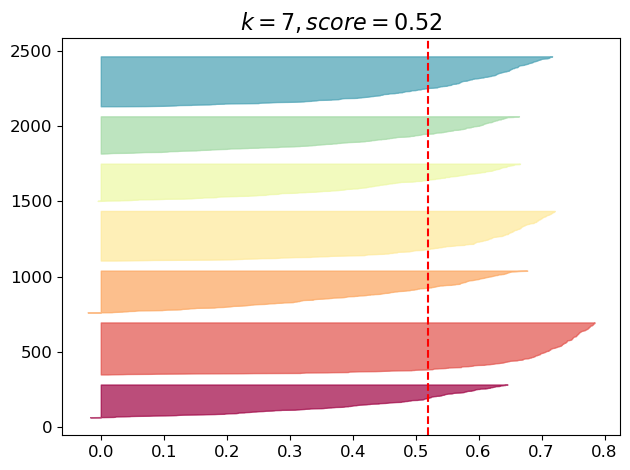

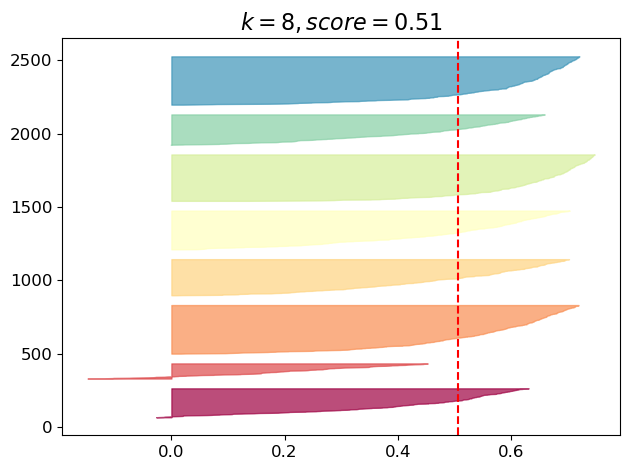

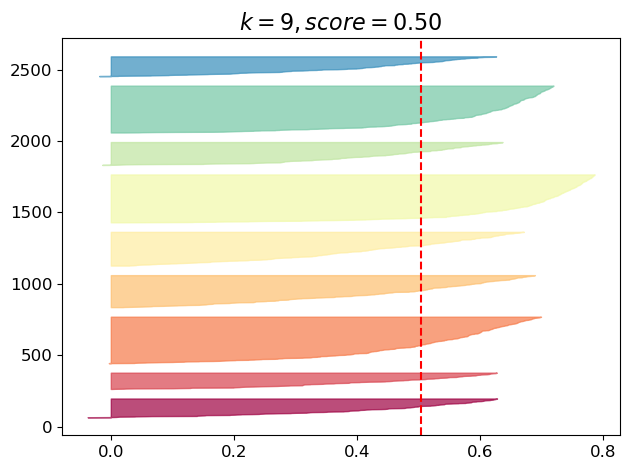

In [16]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import warnings

warnings.filterwarnings("ignore")


def plot_silhouette(model, X):
    mu = model.cluster_centers_
    K, D = mu.shape
    y_pred = model.labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)
    silhouette_scores = silhouette_score(X, model.labels_)
    cmap = cm.get_cmap("Pastel2")
    colors = [cmap(i) for i in range(K)]
    padding = len(X) // 30
    pos = padding
    for i in range(K):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()
        color = mpl.cm.Spectral(i / K)
        # color = colors[i]
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs, facecolor=color, edgecolor=color, alpha=0.7)
        pos += len(coeffs) + padding
    score = silhouette_scores
    plt.axvline(x=score, color="red", linestyle="--")
    plt.title("$k={}, score={:0.2f}$".format(K, score), fontsize=16)


for model in kmeans_per_k:
    K, D = model.cluster_centers_.shape
    plt.figure()
    plot_silhouette(model, X)
    fname = f"kmeans_silhouette_diagram{K}.pdf"
    plt.tight_layout()


We can see in the resulting plots that the silhouettes have different lengths and widths, which indicates a suboptimal clustering. 

---
## 5.2.2 Mini Batch K-Means for high N


::: {.callout-note icon=false}

#### Mini Batch K-Means 

Source: [Scikit-Learn](https://scikit-learn.org/stable/modules/clustering.html#mini-batch-kmeans)

It is a variant of K-Means that uses mini-batches to reduce the computation time. Mini-batches are subsets of the input data, randomly sampled in each training iteration.

In general, the results of Mini Batch K-Means are only slightly worse than the standard algorithm

::: 

![comparisonKmeans_minibatch.png](comparisonKmeans_minibatch.png)

In [17]:
blob_centers = np.array([[0.2, 2.3], [-1.5, 2.3], [-2.8, 1.8], [-2.8, 2.8], [-2.8, 1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=5000, centers=blob_centers, cluster_std=blob_std, random_state=7)

The following code compares the computation times and clustering performance (inertia) of the `KMeans` and `MiniBatchKMeans` algorithms for different numbers of clusters, storing the results in the `times` and `inertias` arrays to plot them. 

50/100

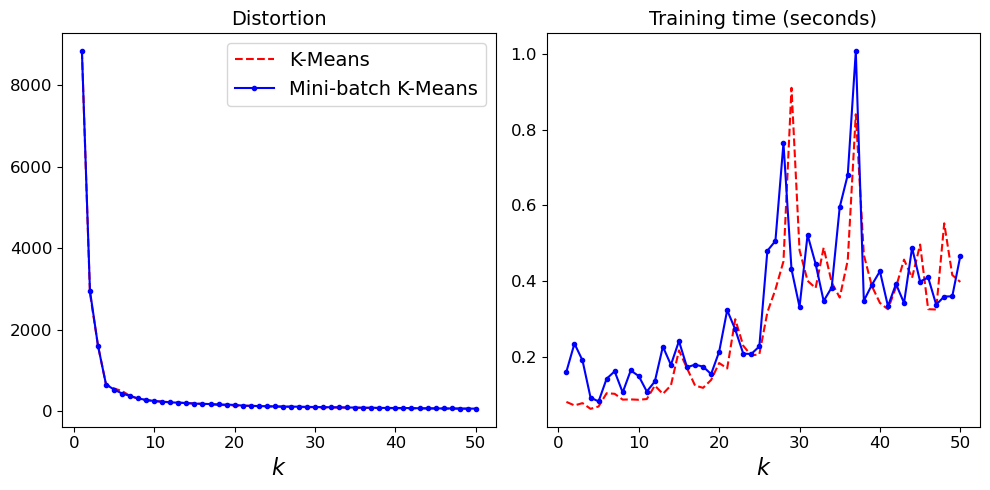

In [18]:
%run -i "kmeans_comparison.py"

## Evaluating the output of clustering methods

::: {.callout-note}
#### The challenge of measuring the quality
Clustering is an unsupervised learning technique, so it is hard to evaluate the quality of the output of any given method. 

If we have labeled data for some of the data, we can use the similarity (or equality) between the labels of two data points as a metric for determining if the two inputs “should” be assigned to the same cluster or not. 

If we don’t have labels, but the method is based on a generative model of the data, we can use log likelihood as a metric. 

For this section, we will use data generated with `make_moons`. You should already be familiar with this. 

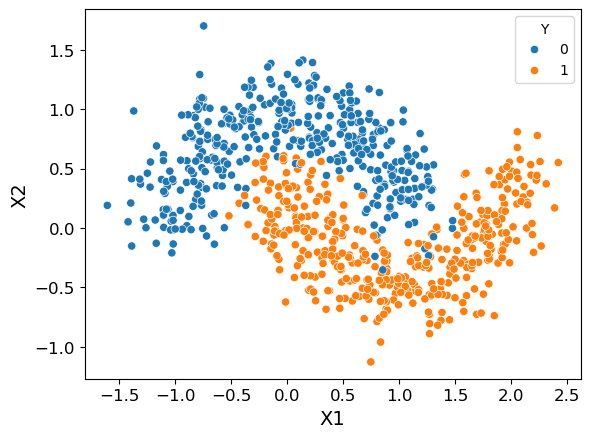

In [19]:
%run -i "make_moons.py"

import seaborn as sns
sns.scatterplot(dfTR, x = "X1", y = "X2", hue="Y");

We will apply a simple K-means with just two clusters for demonstration purposes:

In [20]:
inputs = ['X1', 'X2']
kmeans = KMeans(n_clusters=2, random_state=0).fit(dfTR_eval[inputs])
dfTR_eval['Y_kmeans'] = kmeans.labels_ 

### Purity

::: {.callout-note}
#### Purity
It is a common evaluation metric for clustering algorithms when we have labeled data. It measures the extent to which clusters contain a single class of data points. Higher purity indicates better clustering performance, as it means that the clusters are more homogeneous with respect to the ground truth labels.

The steps are the following:
1. First, we assign each cluster to the class which is most frequent in the cluster: This is done by finding the majority class in each cluster.
2. Count the number of correctly assigned data points: These are the data points that belong to the majority class in their respective clusters.
3. Calculate purity: Purity is the ratio of the number of correctly assigned data points to the total number of data points.

**Mathematically:**

Let $N_{ij}$ be the number of objects in cluster $i$ that belong to class $j$, $K$ is the total number of clusters, and $N$ is the total number of data points in the dataset.The overall purity of a clustering is: 
$$p = \frac{1}{N} \sum_{i=1}^{K} \max_{j} \, N_{ij}$$

We can code a function to calculate this purity:

In [21]:
import numpy as np
from sklearn import metrics

def purity_score(y_true, y_pred):
    contingency_matrix = metrics.cluster.contingency_matrix(y_true, y_pred)

    majority_class_count = np.sum(np.max(contingency_matrix, axis=1)) #Sums the counts of the majority classes (np.max)
    purity = majority_class_count / np.sum(contingency_matrix) 

    return purity

In [22]:
purity_score(dfTR_eval['Y'], dfTR_eval['Y_kmeans'])

np.float64(0.74625)

The purity ranges between 0 (bad) and 1 (good). 

However, we can trivially achieve a purity of 1 by putting each object into its own cluster, so this measure does not penalize for the number of clusters.

### Rand Index


::: {.callout-note}
#### Rand Index
It is a measure of the similarity between two data clusterings (for example, kmeans with the real labeled data)

The Rand Index ranges from 0 to 1, where 1 indicates perfect agreement between the two clusterings.

Let U and V be two different partitions of the N data points. 

For example, U might be the **estimated clustering** and V is **reference clustering** derived from the class
labels. Now define a $2\times2$ contingency table, containing the following numbers: 

- TP (True positives): Count the number of pairs of data points that are in the same cluster in both U and V.
- TN (True negatives): Count the number of pairs of data points that are in different clusters in both U and V.
- FN (False negatives): Count the number of pairs of data points that are in different clusters in U but same in V.
- FP (False positives): Count the number of pairs of data points that are in the same cluster in U but different in V. 

The Rand index is calculated: 
$$R = \frac{TP+ TN}{TP + FP + TN + FN}$$
This can be interpreted as the fraction of clustering decisions that are correct. Clearly $0 \leq R \leq 1$.  
The Rand index weights false positives and false negatives equally.

In `sklearn` we can directly use the `rand_score` function to calculate it. 

In [23]:
from sklearn.metrics.cluster import rand_score
rand_score(dfTR_eval['Y'], dfTR_eval['Y_kmeans'])

0.6208041301627034

::: {.callout-note}
#### Adjusted Rand index
The Adjusted Rand Index (ARI) is a corrected-for-chance version of the Rand Index. It adjusts the Rand Index to account for the fact that random clusterings can sometimes result in a high Rand Index. The ARI ranges from -1 to 1, where 1 indicates perfect agreement between the two clusterings, 0 indicates random labeling, and negative values indicate less agreement than expected by chance.

The formula for the Adjusted Rand Index is:

$$\text{ARI} = \frac{\text{RI} - \text{Expected RI}}{\text{Max RI} - \text{Expected RI}}$$

Where:

* $\text{RI}$ is the Rand Index.
* $\text{Expected RI}$ is the expected value of the Rand Index for random clusterings.
* $\text{Max RI}$ is the maximum value of the Rand Index.

ARI is less sensitive to the absolute sizes of the clusters.

In [24]:
from sklearn.metrics.cluster import adjusted_rand_score
adjusted_rand_score(dfTR_eval['Y'], dfTR_eval['Y_kmeans'])

0.24160736341822675

### Mutual Information

::: {.callout-note}
#### Mutual information
Another way to measure cluster quality is to compute the mutual information between two candidate partitions U and V. 

To do this, let $p_{\text{UV}}(i, j) = \frac{|u_{i}\cap v_{j}|}{N}$ be the probability that a randomly chosen object belongs to cluster $u_{i}$ in U and $v_{j}$ in V. 

Also, let $p_{U}(i) = \frac{|u_{i}|}{N}$ be the probability that a randomly chosen object belongs to cluster $u_{i}$ in U; define $p_{V}(j) = \frac{|v_{J}|}{N}$ be the probability that a randomly chosen object belongs to cluster $v_{j}$ in V. Then we have: 

$$\mathbb{I}(U,V) = \sum_{i=1}^{R}\sum_{j=1}^{C} p_{\text{UV}}(i, j) \text{log} \frac{p_{UV}(i, j)}{p_{U}(i)p_{V}(j)}$$

This lies between $0$ and $\text{min}\{\mathbb{H}(U), \mathbb{H}(V)\}$. Unfortunately, the maximum value can be achieved by using lots of small clusters, which have low entropy. To compensate for this, we can use the **normalized mutual information** which lies between $0$ and $1$.  

$$N\mathbb{I}(U,V) = \frac{2\mathbb{I}(U,V)}{\mathbb{H}(U) + \mathbb{H}(V)}$$

- A score close to 1 indicates that the clusterings are very similar.
- A score close to 0 indicates that the clusterings are dissimilar.

Therefore, a normalized mutual information score closer to 1 indicates that the clustering is good and there is a high degree of agreement between the true labels and the predicted labels. In other words, the clusters found by the algorithm closely match the true underlying clusters.

In [25]:
from sklearn.metrics.cluster import normalized_mutual_info_score
normalized_mutual_info_score(dfTR_eval['Y'], dfTR_eval['Y_kmeans'])

0.18292317096012864

::: {.callout-note}
#### Summary
* Purity presents bias towards many clusters, but it is easy to understand and compute. It is appropriate when you have clear true labels for your data.
* ARI is useful to compare different clustering results on the same dataset, since it accounts for chance grouping. It does not matter if the compared methods have different number of clusters.
* Mutual information to measure the amount of information shared between clustering and the true labels. It is not biased towards a specific number of clusters. 

---

## 5.2.3 Hierarchical Agglomerative Clustering


::: {.callout-note icon=false}

#### HAC

A common form of clustering is known as **hierarchical agglomerative clustering or HAC**. 

This is an alternative to prototype-based clustering (e.g., K-means) that allows us to plot dendrograms. Another advantages is that we don't have to specify the number of clusters upfront.

In HAC, we start with each example as an individual cluster and merge the closest pairs of clusters until only one cluster remains. 

::: 


For example, consider the set of $5$ inputs points below in $x_n \in \mathbb{R}^2$. 


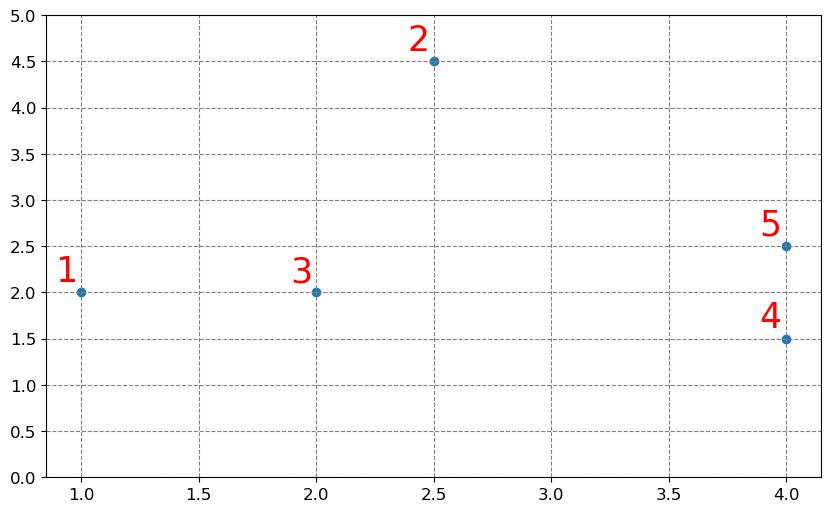

In [26]:
%run -i "example_hac_1.py"

the input to the algorithm is an $N \times N$ dissimilarity matrix $D_{ij}\geq0$, and the output is a tree structure in which groups i and j with small disimilarity are grouped together in a hierarchical fashion.

We will use **city block distance** between the points to define the dissimilarity, i.e. 

$$d_{ij} = \sum_{k=1}^{2}|x_{ik}-x_{jk}|$$

We start with a tree with $N$ leaves (in this example, $N=5$), each corresponding to a cluster with a single data point. Next
we compute the pair of points that are closest, and merge them:
* We see that (1,3) and (4,5) are both distance 1 apart, so they get merged first.
*  We then measure the dissimilarity between the sets {1,3}, {4,5} and {2} using some measure (details below), and group them, and repeat

The result is a binary tree known as a **dendrogram**. By cutting this tree at different heights, we can induce a different number of (nested) clusters.

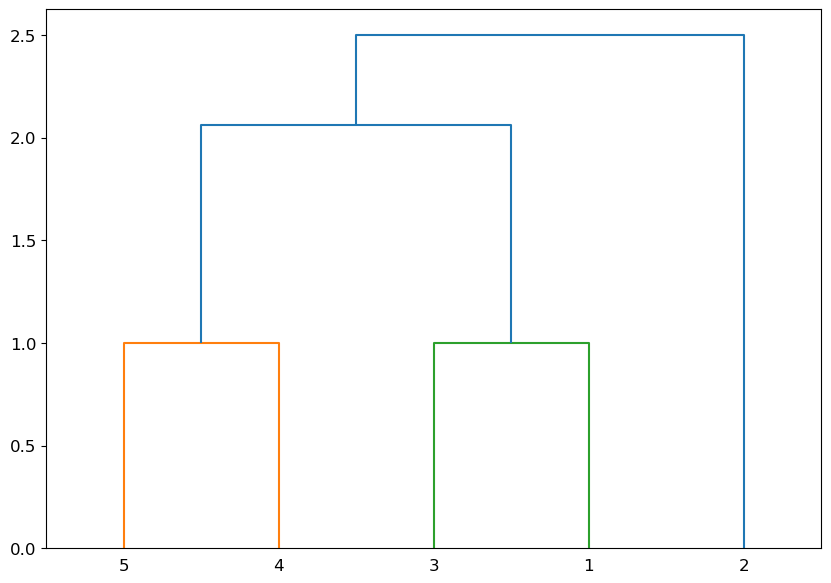

In [27]:
linked = linkage(X, 'single')
labelList = range(1, 6)
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', labels=labelList, distance_sort='descending', show_leaf_counts=True)
plt.show()

::: {.callout-important}
#### How to interpret a dendrogram
- The dendrogram visually represents the hierarchical clustering of the data.
- The vertical lines represent the distances or dissimilarities between clusters.
- The height at which two clusters are merged indicates the distance at which they were merged.
- The truncation (truncate_mode='lastp') allows you to focus on the final stages of the clustering process, showing only the last p merged clusters.

Some times, you may want to plot the dendrogram with a heat map, to represent each individual value in the data array / matrix with a color code. 

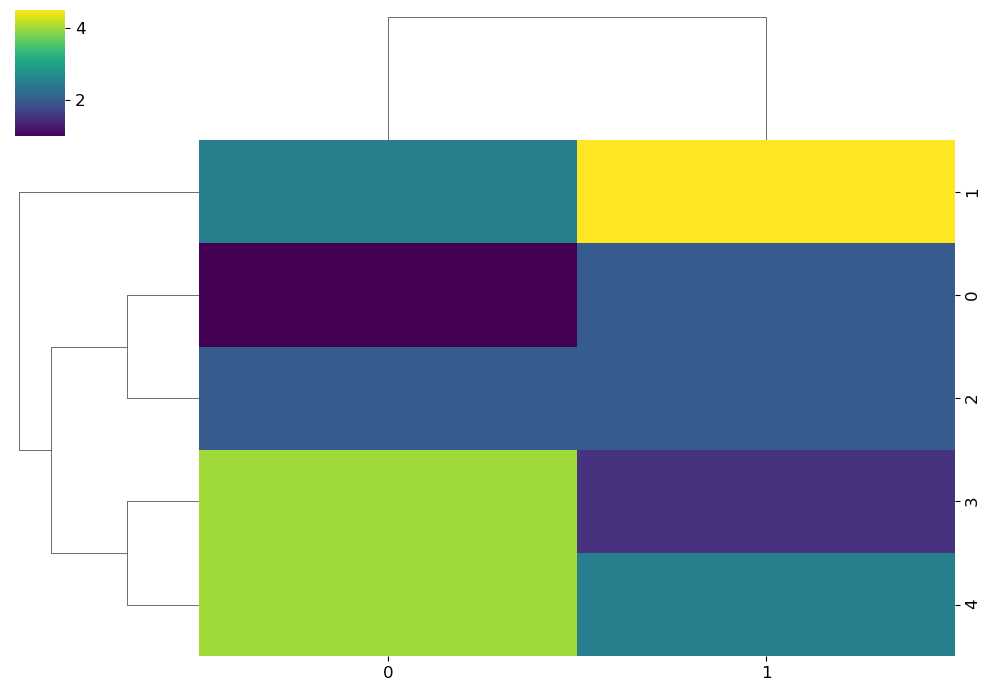

In [28]:
import seaborn as sns

sns.clustermap(X, method='single', cmap='viridis', figsize=(10, 7))
plt.show()


::: {.callout-tip icon=false}

#### Think about it...

Take a moment to interpret previous heatmap.

::: 

::: {.callout-note}
#### The linkage matrix
To plot the dendrogram, we performed a `single` linkage (we will see what this means in the next subsection). We did this using this code:

`linked = linkage(X, 'single')`

**But what was stored by `linked`?** 

`linked` stores the linkage matrix, which describes the hierarchical clustering process. This matrix has dimensions $(n-1)\times 4$. The reason for these dimensiones are:

* **Number of merges**: In hierarchical clustering, each step involves merging two clusters. Since there are $n$ initial clusters (each data point is its own cluster), it takes $n-1$ steps to merge all clusters into a single cluster. Therefore, the linkage matrix has $n-1$ rows, each representing one merge.
* **Columns of the linkage matrix**: Each row in the matrix contains four values:
    - The indices of the two clusters that are merged in that step. (two columns)
    - The distance (or dissimilarity) between the merged clusters. (one column)
    - The number of original observations in the newly formed cluster. (one column)

In [29]:
# (n-1)x 4
linked.shape

(4, 4)

In [30]:
linked[3]

array([1. , 7. , 2.5, 5. ])

### 5.2.3.1 Single link

In single link clustering, also called **nearest neighbor clustering**, the distance between two groups G and H is defined as the distance between the **two closest members of each group**: 

$$d_{SL}(U,V) = min_{i\in G,j \in H} d_{i, j}$$

The tree built using single link clustering is a minimum spanning tree of the data, which is a tree that connects all the objects in a way that minimizes the sum of the edge weights (distances). (**Minimal intercluster dissimilarity**)

To see this, note that when we merge two clusters, we connect together the two closest members of the clusters; this adds an edge between the corresponding nodes, and this is guaranteed to be the “lightest weight” edge joining these two clusters. And once two clusters have been merged, they will never be considered again, so we cannot create cycles. 

In [31]:
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import pdist

clustering = AgglomerativeClustering(linkage='single', metric='manhattan').fit(dfTR)
cityDist = pdist(dfTR, 'cityblock')

In [32]:
adjusted_rand_score(dfTS_eval['Y'], clustering.fit_predict(dfTS_eval))

0.827232603488166

In [33]:
normalized_mutual_info_score(dfTS_eval['Y'], clustering.fit_predict(dfTS_eval))

0.7386721149855451

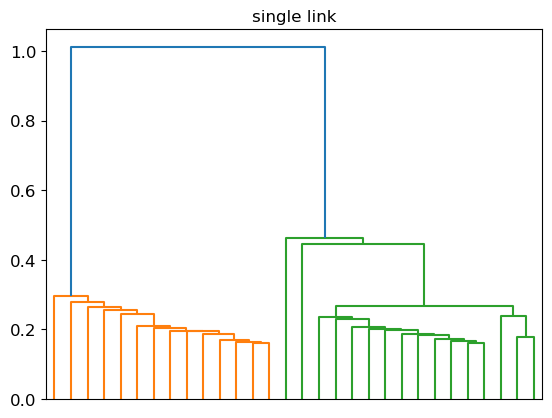

In [34]:
import scipy 

plt.figure()
Z = scipy.cluster.hierarchy.linkage(cityDist, 'single')
scipy.cluster.hierarchy.dendrogram(Z, truncate_mode='lastp')
plt.title('single link')
plt.tick_params(labelbottom=False)
plt.show()

### 5.2.3.2 Complete link 

In complete link clustering, also called **furthest neighbor clustering**, the distance between two groups is defined as the distance between the **two most distant pairs**:

$$ d_{CL}(G,H) = \text{max}_{i\in G, j \in H} d_{i,j}$$

* **Single linkage** only requires that a single pair of objects be close for the two groups to be considered close together, regardless of the similarity of the other members of the group. Thus clusters can be formed that violate the compactness property, which says that all the observations within a group should be similar to each other. 

* **Complete linkage** represents the opposite extreme: two groups are considered close only if all of the observations in their union are relatively similar. This will tend to produce clusterings with small diameter, i.e., compact clusters.

In [35]:
clustering = AgglomerativeClustering(n_clusters = 2, linkage='complete', metric='euclidean').fit(dfTR)
cityDist = pdist(dfTR, 'cityblock')

In [36]:
np.unique(clustering.labels_)

array([0, 1])

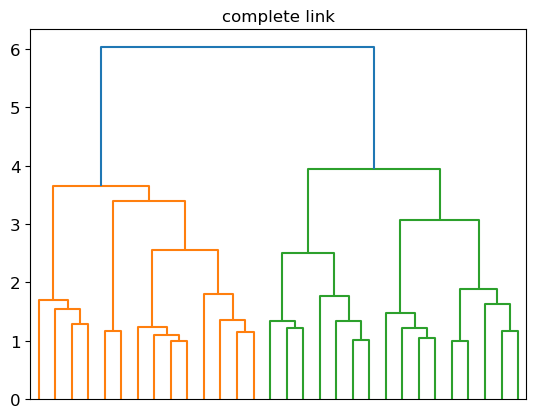

In [37]:
plt.figure()
Z = scipy.cluster.hierarchy.linkage(cityDist, 'complete')
scipy.cluster.hierarchy.dendrogram(Z, truncate_mode='lastp')
plt.title('complete link')
plt.tick_params(labelbottom=False)
plt.show()

### 5.2.3.3 Average link 

In practice, the preferred method is average link clustering, which measures the average distance between all pairs:

$$d_{avg}(G,H)= \frac{1}{n_{G}n_{H}} \sum_{i\in G}\sum_{j\in H} d_{i,j},$$
where $n_{G}$ and $n_{H}$ are the elements in the groups $G$ and $H$. 

In [38]:
clustering = AgglomerativeClustering(linkage='average', metric='manhattan').fit(dfTR)
cityDist = pdist(dfTR, 'cityblock')

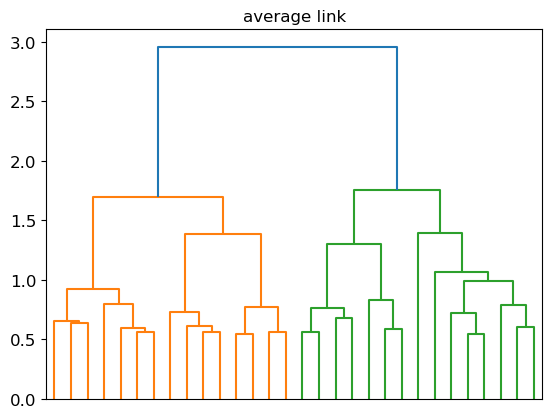

In [39]:
plt.figure()
Z = scipy.cluster.hierarchy.linkage(cityDist, method='average')
scipy.cluster.hierarchy.dendrogram(Z, truncate_mode='lastp')
plt.title('average link')
plt.tick_params(labelbottom=False)
plt.show()

::: {.callout-note icon=false}

#### Average link

Average link clustering represents a compromise between single and complete link clustering. It tends to produce relatively compact clusters that are relatively far apart. 

However, since it involves averaging of the $d_{i,j}$, any change to the measurement scale can change the result. In contrast, single linkage and complete linkage are invariant to monotonic transformations of $d_{i,j}$, since they leave the relative ordering the same.

::: 


::: {.callout-tip icon=false}

#### Think about it...

Take a moment to compare the dendrograms generated with the single, complete and average link HAC.. Do you see the differences? 

::: 

### 5.2.3.4 Ward Linkage

Ward proposed that the loss of information that occurs when integrating the different individuals in clusters can be measured through the total sum of the squares of the deviations between each point (individual) and the mean of the cluster in which it is integrated.

In order for the clustering process to be optimal, in the sense that the groups formed do not distort the original data, he proposed the following strategy:

::: {.callout icon=false}
At each step of the analysis, consider the possibility of the union of each pair of groups and opt for the merger of those two groups that least increase the sum of squares of the deviations when joined.

::: 

$$d_{ward}(u,v) = \sqrt{\frac{|v| + |s|}{T}d(v,s)^{2} + \frac{|v| + |t|}{T}d(v,t)^{2} - \frac{|v|}{T}d(s,t)^{2}}$$

where $u$ is the newly joined cluster consisting of clusters $s$ and $t$, $v$ is an unused cluster in the forest, and $T = |v| + |s| + |t|$ is the cardinality. 

::: {.callout-note icon=false}
Ward's method is one of the most widely used in practice; it has almost all the advantages of the average method and is usually more discriminative in determining the levels of clustering since *it minimizes the variance of the clusters being merged*.

::: 


In [40]:
clustering = AgglomerativeClustering(linkage='ward', metric='euclidean').fit(dfTR)
cityDist = pdist(dfTR, 'euclidean')

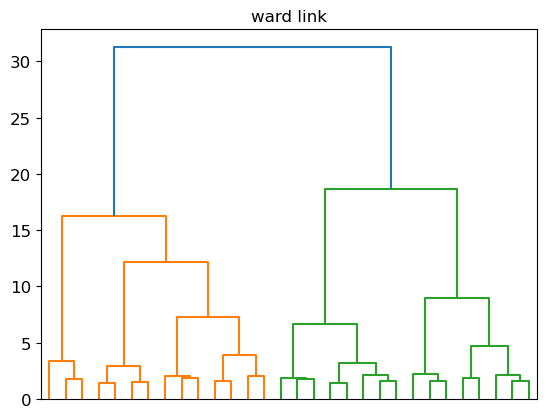

In [41]:
plt.figure()
Z = scipy.cluster.hierarchy.linkage(cityDist, method='ward')
scipy.cluster.hierarchy.dendrogram(Z, truncate_mode='lastp')
plt.title('ward link')
plt.tick_params(labelbottom=False)
plt.show()

::: {.callout-important icon=false}
There are several problems with **hierarchical agglomerative clustering**:
* First, it takes $O(N^3)$ time (for the average link method), making it hard to apply to big datasets. 
* Second, it assumes that a dissimilarity matrix has already been computed, whereas the notion of “similarity” is often unclear and needs to be learned. 
* Third, it is just an algorithm, not a model, and so it is hard to evaluate how good it is. That is, there is no clear objective that it is optimizing. 


On the other hand, the **K-means algorithm** addresses these issues: 

- First, it runs in $O(NKT)$ time, where T is the number of iterations. 

- Second, it computes similarity in terms of Euclidean distance to **learned cluster centers $μ_{k} \in \mathbb{R}^{D}$**, rather than requiring a dissimilarity matrix. 

- Third, **it optimizes a well-defined cost function**, as we will see.

::: 


### Comparing Hierarchical Agglomerative Clustering algorithms

[Code taken from sklearn](https://scikit-learn.org/stable/auto_examples/cluster/plot_cluster_comparison.html)

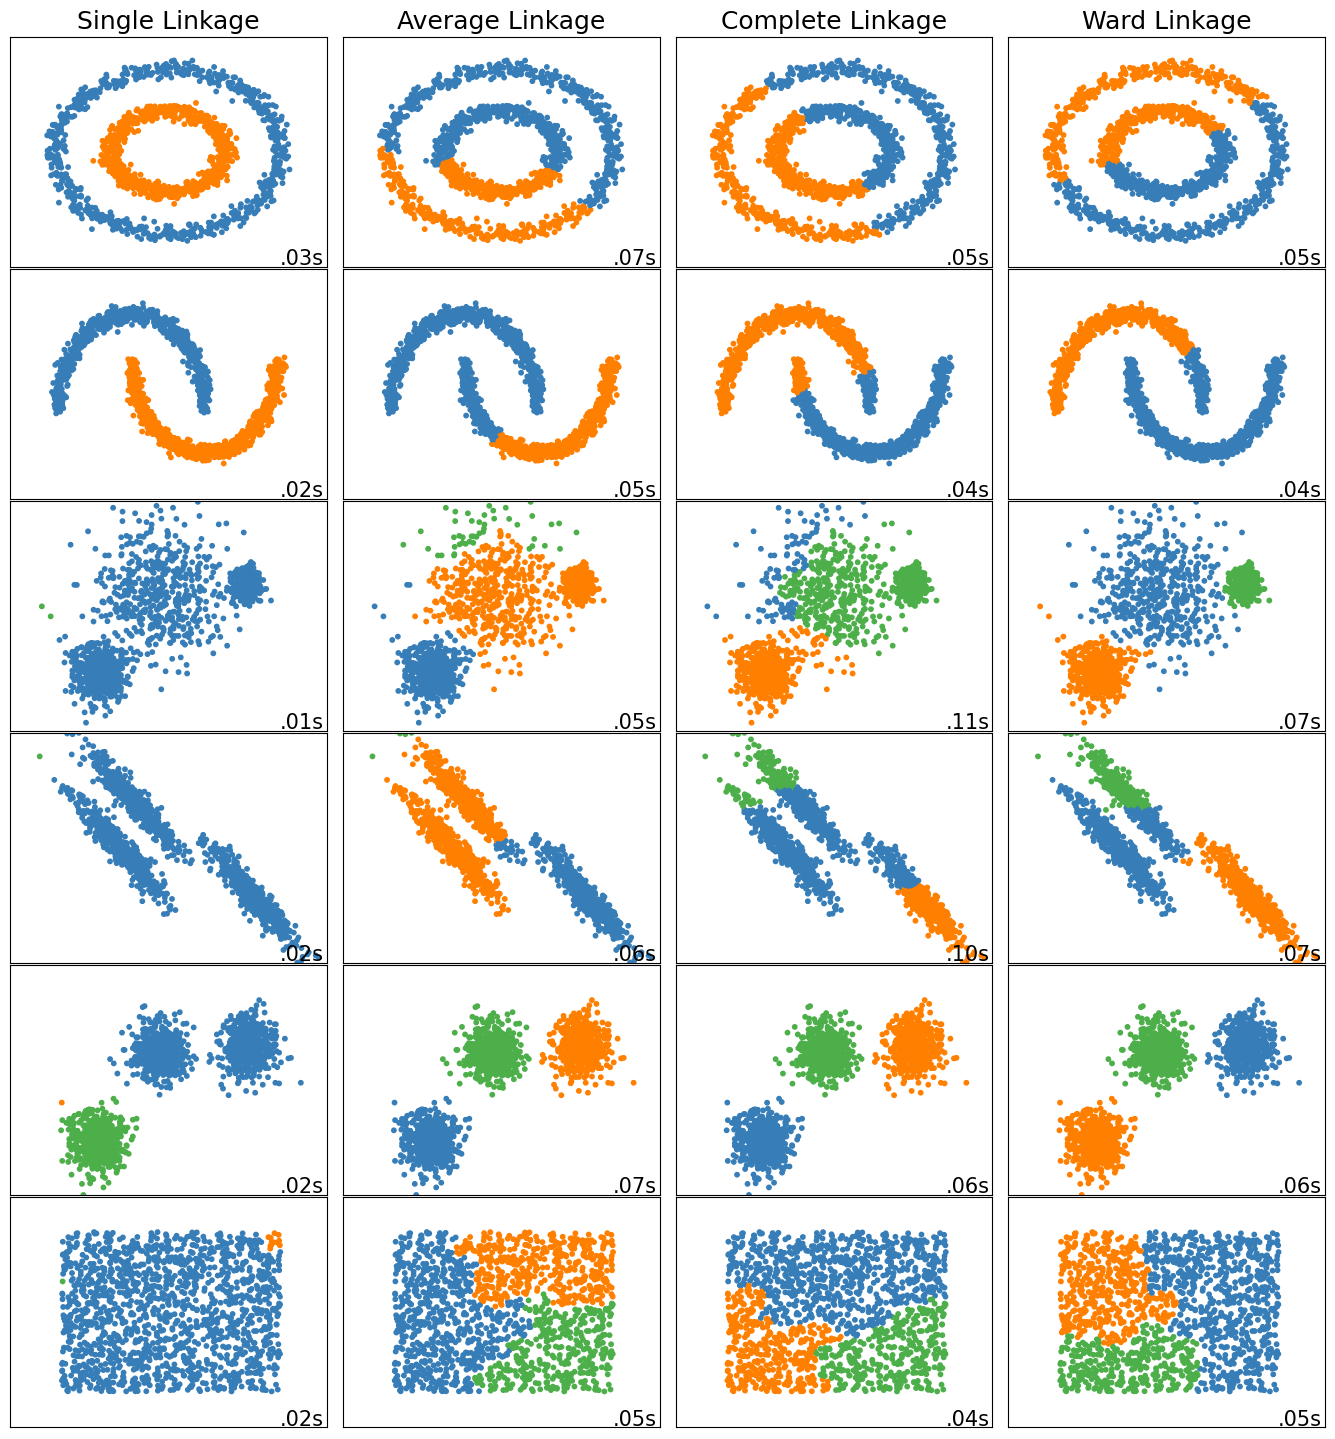

In [42]:
%run -i 'plot_linkage_comparison.py'

`Interesting Links`

- [When clustering doesnt make sense](https://towardsdatascience.com/when-clustering-doesnt-make-sense-c6ed9a89e9e6)
- [Evaluation metrics](https://www.cs.upc.edu/~bejar/URL/material/04-Validation.pdf)
- [KMeans visually explained](https://www.youtube.com/watch?v=4qJWhvFQb9g&t=0s)

## Example 

### With Hierarchical Agglomerative Clustering (HAC)

To se HAC in action, we will use the yeast dataset stored in `yeastData310.mat`

::: {.callout-note}
#### The yeast dataset
The yeast dataset consists of gene expression data for 300 genes, each measured at 7 different time points. This dataset is often used in bioinformatics and machine learning to study the temporal patterns of gene expression in response to various stimuli or conditions.

Each row in the dataset represents a single gene, and each column represents a measurement taken at a specific time point. ($N = 300$ genes at $T = 7$ points. Thus each data sample is a vector $x_n \in \mathbb{R}^{7}$)

The measurements capture the expression levels of the genes, which can vary over time. This temporal data can be used to identify genes with similar expression patterns, understand gene regulatory mechanisms, and discover potential biomarkers.

In [43]:
import scipy.io
import matplotlib.pyplot as plt
path = './yeastData310.mat'
data = scipy.io.loadmat(path)
X = data['X']

::: {.callout-note}
#### Note
Notice that in this case we have the data stored as a `.mat` file (binary format used by MATLAB). To load this data in python we need the `scipy` library, not pandas.

:::

Let's plot the data. 

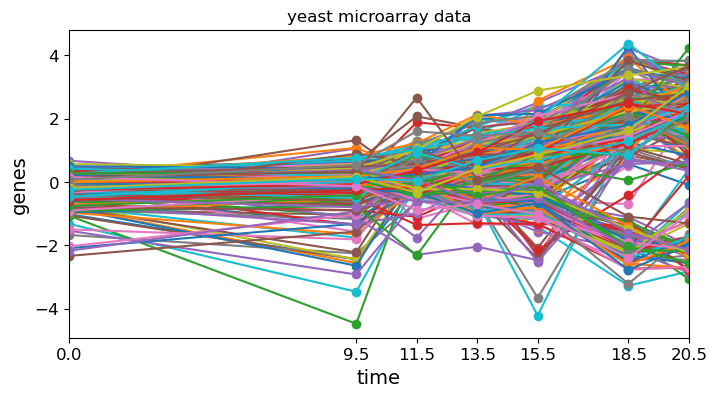

In [44]:
times = data['times']
X = X.transpose()
times = times.reshape((7,))
# yeast gene expression data plotted as a time series
plt.figure(figsize=(8, 4))
plt.plot(times, X, 'o-')
plt.title('yeast microarray data')
plt.xlabel('time')
plt.ylabel('genes')
plt.xlim([0, max(times)])
plt.xticks(ticks=times, labels=times)
plt.show();

We see that there are several kinds of genes, such as those whose expression level goes up monotonically over time (in response to a given stimulus), those whose expression level goes down monotonically, and those with more complex response patterns.

::: {.callout-tip}
#### Think about it...
If we can notice that the level of some genes go up over time and, for some others, it goes down, we may group these genes into clusters. In this case, we would not be grouping "points" but "series" of points. 


We can also plot this data in a heatmap with the genes y the y-axis and time in the x-axis. The colour will indicate the number the expression level. 

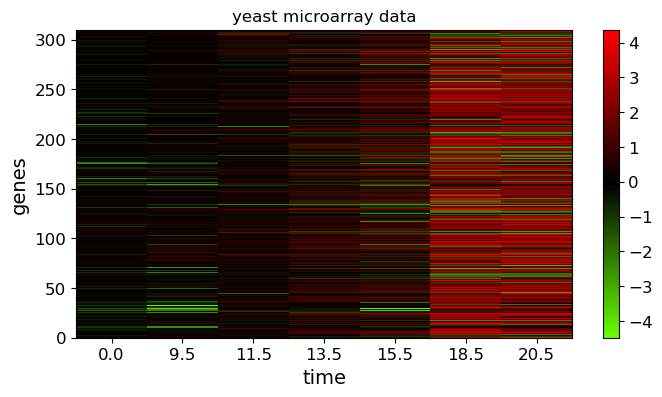

In [45]:
# yeast gene expression data plotted as a heat map
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

plt.figure(figsize=(8, 4))
basic_cols = ['#66ff00', '#000000', '#FF0000']  # green-black-red
my_cmap = LinearSegmentedColormap.from_list('mycmap', basic_cols)
plt.xticks(ticks=[i + 0.5 for i in range(0, 7)], labels=times)
plt.pcolormesh(X.transpose(), cmap=my_cmap)
plt.title('yeast microarray data')
plt.xlabel('time')
plt.ylabel('genes')
plt.colorbar()
plt.show()

::: {.callout-note}
#### Approach
In this example, we will use **correlation distance** to compute a pairwise dissimilarity matrix $D  \in \mathbb{R}^{300\times 300}$, and then we will apply **HAC** using **ward linkage**.

**Correlation distance** is a measure of dissimilarity between two vectors that is derived from the Pearson correlation coefficient: 

$\text{Correlation Distance} = 1 - \text{Pearson Correlation Coefficient}$

This transformation converts the correlation coefficient into a distance metric that ranges from 0 to 2, where:

* A correlation distance of 0 indicates that the two vectors are perfectly correlated (either positively or negatively).
* A correlation distance of 1 indicates no correlation between the vectors.
* A correlation distance of 2 indicates that the two vectors are perfectly anti-correlated.

::: {.callout-note}
#### But.. why correlation distance?
As you have noticed, we are working with time series in this dataset. Correlation distance is particularly effective for identifying patterns in high-dimensional data such as time series data. 

In [46]:
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering
import numpy as np

X = data['X']

corrX = pdist(X, 'correlation')

Z = scipy.cluster.hierarchy.linkage(corrX, method='ward')

::: {.callout-tip}
#### Exercise
Do you remember what was stored in `Z`? What is its shape?

Let's plot the dendrogram:

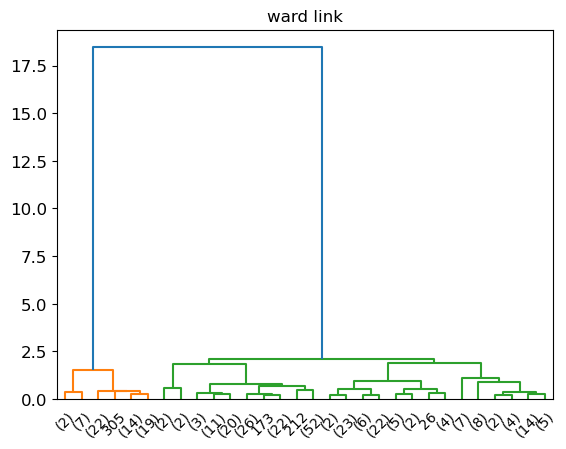

In [47]:
plt.figure()
scipy.cluster.hierarchy.dendrogram(Z, truncate_mode='lastp')
plt.title('ward link')
plt.tick_params(labelbottom=True)
#plt.axhline(y=, c='grey', lw=1, linestyle='dashed')
plt.show()

::: {.callout-note}
#### Just to remember...
Interpretation of the Dendrogram:

- The dendrogram visually represents the hierarchical clustering of the data.
- The vertical lines represent the distances or dissimilarities between clusters.
- The height at which two clusters are merged indicates the distance at which they were merged.
- The truncation (truncate_mode='lastp') allows you to focus on the final stages of the clustering process, showing only the last p merged clusters.

::: {.callout-tip}
#### Question
How many clusters would you set based on the previous dendrogram? 

In [53]:

clusterTree = AgglomerativeClustering(n_clusters=6, linkage='ward', metric='euclidean', compute_full_tree=True) 
clusterTree.fit(X)
clusters = clusterTree.labels_

nclusters = 1 + np.amax(clusterTree.labels_)
print(f"Number of clusters = {nclusters}")


Number of clusters = 6


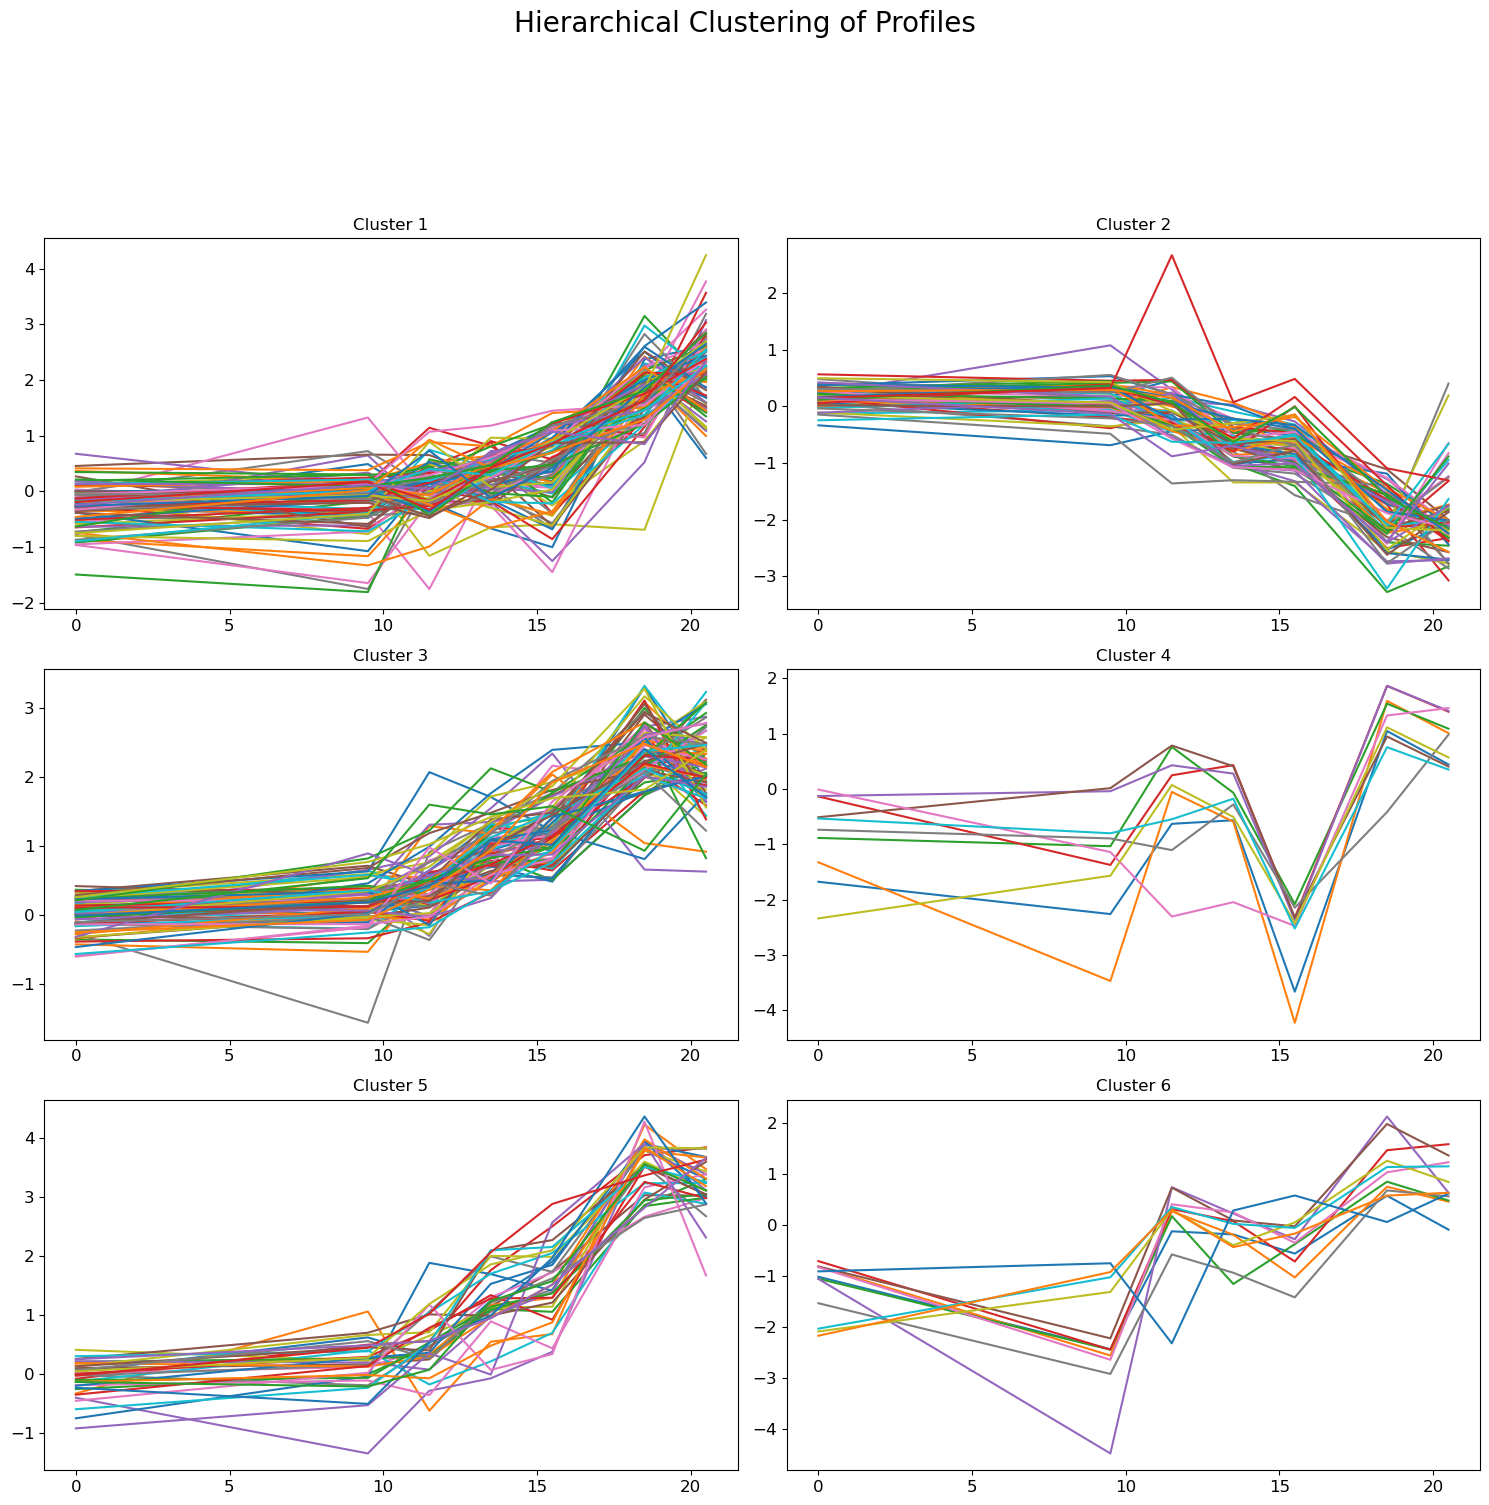

In [54]:
import math

# Calculate the number of rows and columns needed
rows = math.ceil(math.sqrt(nclusters))
cols = math.ceil(nclusters / rows)

fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
fig.suptitle('Hierarchical Clustering of Profiles', y=1, fontsize=20)
times = data['times'].reshape(7, )

for c in range(nclusters):
    occurences = np.argwhere(clusters == c)
    row = c // cols
    col = c % cols
    for occ in occurences:
        axes[row, col].plot(times, X[occ, :].reshape(7,))
    axes[row, col].set_title(f'Cluster {c+1}')

# Hide any empty subplots
for i in range(nclusters, rows * cols):
    fig.delaxes(axes.flatten()[i])

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

::: {.callout-tip}
#### Play!
Play with the number of clusters and see if the plot makes sense with the initial dendrogram

### With Kmeans

Now, instead of HAC, we are going to apply k-means to the yeast dataset. Let's load the dataset and apply kmeans.

In [55]:
path = './yeastData310.mat'
data = scipy.io.loadmat(path)
X = data['X']

In [56]:
kmeans = KMeans(n_clusters=16, n_init=10, random_state=0, algorithm='lloyd').fit(X)
times = data['times']
X = X.transpose() #Just to facilitate plotting

In [57]:
labels = kmeans.labels_
clu_cen = kmeans.cluster_centers_

::: {.callout-tip}
#### Question
What is stored in `labels`? And in `clu_cen`? What is their shape?

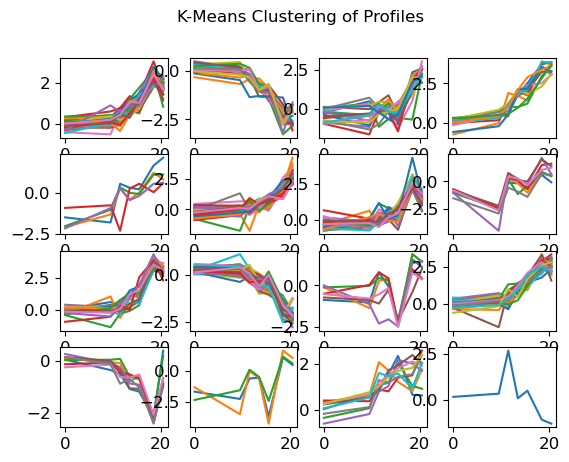

In [58]:
clusters = [[] for i in range(0, 16)]

for (i, l) in enumerate(labels):
    clusters[l].append(i)

times = times.reshape((7,))

plt.figure()
for l in range(0, 16):
    plt.subplot(4, 4, l + 1)
    if clusters[l] != []:
        plt.plot(times, X[:, clusters[l]])
plt.suptitle("K-Means Clustering of Profiles")
plt.show()

In the previous figure we have plotted each cluster. It is also interesting to plot the centroids of these clusters (7 centroids for each cluster, as we have data for seven points in time). This way, we can visualize the 16 clusters centers as prototypical time series. 

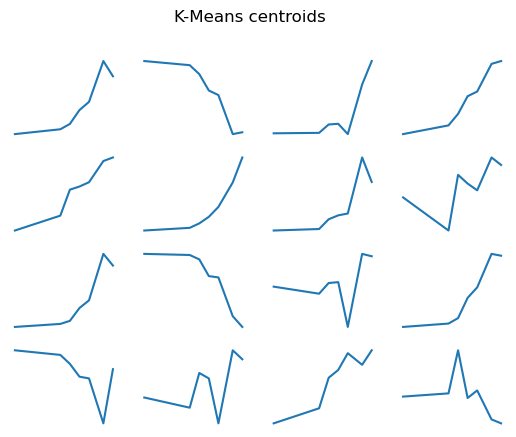

In [182]:
plt.figure()
for l in range(0, 16):
    plt.subplot(4, 4, l + 1).axis('off')
    plt.plot(times, clu_cen[l, :])
plt.suptitle("K-Means centroids")
plt.show()

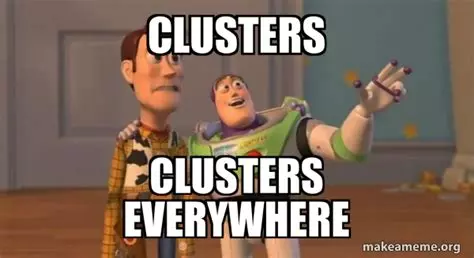